In [19]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten



In [11]:
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

In [12]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

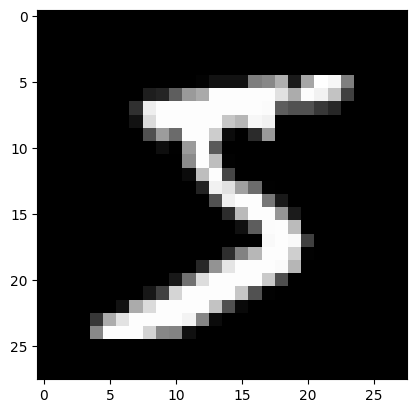

In [16]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0],cmap="gray")


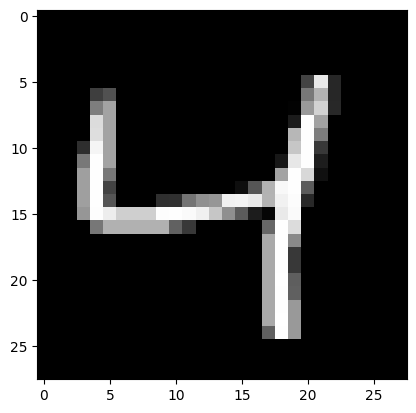

In [14]:
plt.imshow(x_train[2],cmap="gray")


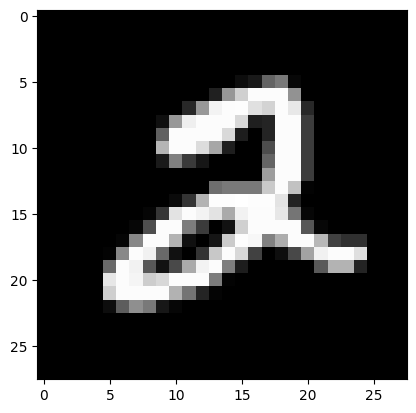

In [15]:
plt.imshow(x_train[5],cmap="gray")

In [18]:
x_train=x_train/255.0
x_test=x_test/255.0

In [20]:
model=Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation="relu"))
model.add(Dense(10,activation="softmax"))



/home/karan/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1779685718.523416   58228 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [24]:
model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10


2026-05-25 05:13:45.299143: I external/local_xla/xla/service/service.cc:163] XLA service 0x7234a80050a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-25 05:13:45.299177: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2026-05-25 05:13:45.378034: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-25 05:13:45.570980: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-05-25 05:13:45.645690: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-25 05:13

  44/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4743 - loss: 1.7242 

I0000 00:00:1779686028.243543   59709 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9181 - loss: 0.2877 - val_accuracy: 0.9552 - val_loss: 0.1557
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9623 - loss: 0.1290 - val_accuracy: 0.9658 - val_loss: 0.1147
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9728 - loss: 0.0881 - val_accuracy: 0.9647 - val_loss: 0.1086
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9806 - loss: 0.0648 - val_accuracy: 0.9679 - val_loss: 0.1045
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9848 - loss: 0.0502 - val_accuracy: 0.9735 - val_loss: 0.0901
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9879 - loss: 0.0402 - val_accuracy: 0.9728 - val_loss: 0.0969
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9909 - loss: 0.0292 - val_accuracy: 0.9754 - val_loss: 0.0841
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9924 - loss: 0.0248 - val_accurac

In [25]:
y_prob=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [30]:
y_prob

array([[1.1840711e-09, 2.7415889e-12, 3.7349277e-08, ..., 9.9999881e-01,
        4.0440447e-09, 5.7352654e-08],
       [1.6071044e-10, 8.4219719e-05, 9.9991560e-01, ..., 6.1874707e-19,
        1.7654050e-07, 3.0613672e-15],
       [9.7660093e-09, 9.9954516e-01, 5.9777045e-05, ..., 7.6963632e-05,
        2.8043441e-04, 3.9026617e-08],
       ...,
       [1.7143455e-16, 3.2430761e-13, 1.3202485e-16, ..., 4.0950918e-09,
        9.9128587e-11, 1.3576430e-07],
       [3.4461001e-16, 1.7582703e-16, 2.7929611e-17, ..., 8.5712171e-17,
        2.1897984e-08, 1.4293001e-16],
       [3.6840420e-11, 8.0979997e-16, 2.0524424e-11, ..., 1.2805950e-17,
        5.4988203e-13, 6.5250243e-15]], shape=(10000, 10), dtype=float32)

In [29]:
y_prob.argmax(axis=1)

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_prob.argmax(axis=1))

0.9776